In [ ]:
import sys
assert sys.version_info >= (3, 5)

import tensorflow as tf
assert tf.__version__ >= "2.0"

import numpy as np
import os

from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print(sys.version)
print('TF version: ', tf.__version__)
print('Keras version: ', keras.__version__)
print('GPU is', 'available' if tf.config.list_physical_devices('GPU') else 'NOT AVAILABLE')

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TF version:  2.19.0
Keras version:  3.10.0
GPU is available


In [ ]:
#Todas as bibliotecas
import pathlib
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint
import pandas as pd
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
import time

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Importar Datasets

Dataset 1

In [ ]:
data_dir = '/content/drive/MyDrive/Dataset 1'
dataset1 = os.listdir(data_dir)

print(dataset1)

['training_data', 'testing_data']


In [ ]:
IMG_SIZE = (160, 160)

data_dir_1 = pathlib.Path('/content/drive/MyDrive/Dataset 1')
test_dir_1 = os.path.join(str(data_dir_1), 'testing_data')
train_dir_1 = os.path.join(str(data_dir_1), 'training_data')

test_ds_1 = image_dataset_from_directory(test_dir_1, shuffle=True, seed=11, image_size=IMG_SIZE)
ds1_train = image_dataset_from_directory(train_dir_1, shuffle=True, seed=11, image_size=IMG_SIZE)

test_ds_1 = test_ds_1.cache().prefetch(1)
ds1_train = ds1_train.cache().prefetch(1)

Found 325 files belonging to 2 classes.
Found 703 files belonging to 2 classes.


In [ ]:
batch_size = 32
IMG_SIZE = (160, 160)

train_ds_1 = keras.preprocessing.image_dataset_from_directory(
    train_dir_1,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

val_ds_1 = keras.preprocessing.image_dataset_from_directory(
    train_dir_1,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

class_names_1 = train_ds_1.class_names

train_ds_1 = train_ds_1.cache().prefetch(1)
val_ds_1 = val_ds_1.cache().prefetch(1)

Found 703 files belonging to 2 classes.
Using 563 files for training.
Found 703 files belonging to 2 classes.
Using 140 files for validation.


In [ ]:
print(class_names_1)

['cracked', 'normal']


In [ ]:
count_normal = 0
count_cracked = 0

for images, labels in train_ds_1:
    labels = labels.numpy()
    count_cracked += np.sum(labels == class_names_1.index('cracked'))
    count_normal += np.sum(labels == class_names_1.index('normal'))


print(f'Normal: {count_normal}')
print(f'Cracked: {count_cracked}')

Normal: 302
Cracked: 261


Dataset 2

In [ ]:
data_dir = '/content/drive/MyDrive/Dataset 2'
dataset2 = os.listdir(data_dir)

print(dataset2)

['testing_data', 'training_data']


In [ ]:
IMG_SIZE = (160, 160)

data_dir_2 = pathlib.Path('/content/drive/MyDrive/Dataset 2')
test_dir_2 = os.path.join(str(data_dir_2), 'testing_data')
train_dir_2 = os.path.join(str(data_dir_2), 'training_data')

test_ds_2 = image_dataset_from_directory(test_dir_2, shuffle=True, seed=11, image_size=IMG_SIZE)
ds2_train = image_dataset_from_directory(train_dir_2, shuffle=True, seed=11, image_size=IMG_SIZE)

test_ds_2 = test_ds_2.cache().prefetch(1)
ds2_train = ds2_train.cache().prefetch(1)

Found 372 files belonging to 2 classes.
Found 1484 files belonging to 2 classes.


In [ ]:
batch_size = 32
IMG_SIZE = (160, 160)

train_ds_2 = keras.preprocessing.image_dataset_from_directory(
    train_dir_2,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

val_ds_2 = keras.preprocessing.image_dataset_from_directory(
    train_dir_2,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

class_names_2 = train_ds_2.class_names

train_ds_2 = train_ds_2.cache().prefetch(1)
val_ds_2 = val_ds_2.cache().prefetch(1)


Found 1484 files belonging to 2 classes.
Using 1188 files for training.
Found 1484 files belonging to 2 classes.
Using 296 files for validation.


In [ ]:
count_normal = 0
count_cracked = 0

for images, labels in train_ds_2:
    labels = labels.numpy()
    count_cracked += np.sum(labels == class_names_2.index('cracked'))
    count_normal += np.sum(labels == class_names_2.index('normal'))


print(f'Normal: {count_normal}')
print(f'Cracked: {count_cracked}')

Normal: 532
Cracked: 656


Dataset 3

In [ ]:
data_dir = '/content/drive/MyDrive/Dataset 3'
dataset3 = os.listdir(data_dir)

print(dataset3)

['testing_data', 'training_data']


In [ ]:
IMG_SIZE = (160, 160)

data_dir_3 = pathlib.Path('/content/drive/MyDrive/Dataset 3')
test_dir_3 = os.path.join(str(data_dir_3), 'testing_data')
train_dir_3 = os.path.join(str(data_dir_3), 'training_data')

test_ds_3 = image_dataset_from_directory(test_dir_3, shuffle=True, seed=11, image_size=IMG_SIZE)
ds3_train = image_dataset_from_directory(train_dir_3, shuffle=True, seed=11, image_size=IMG_SIZE)

test_ds_3 = test_ds_3.cache().prefetch(1)
ds3_train = ds3_train.cache().prefetch(1)

Found 345 files belonging to 2 classes.
Found 1353 files belonging to 2 classes.


In [ ]:
batch_size = 32
IMG_SIZE = (160, 160)

train_ds_3 = keras.preprocessing.image_dataset_from_directory(
    train_dir_3,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

val_ds_3 = keras.preprocessing.image_dataset_from_directory(
    train_dir_3,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

class_names_3 = train_ds_3.class_names

train_ds_3 = train_ds_3.cache().prefetch(1)
val_ds_3 = val_ds_3.cache().prefetch(1)

Found 1353 files belonging to 2 classes.
Using 1083 files for training.
Found 1353 files belonging to 2 classes.
Using 270 files for validation.


In [ ]:
count_normal = 0
count_cracked = 0

for images, labels in train_ds_3:
    labels = labels.numpy()
    count_cracked += np.sum(labels == class_names_3.index('cracked'))
    count_normal += np.sum(labels == class_names_3.index('normal'))


print(f'Normal: {count_normal}')
print(f'Cracked: {count_cracked}')

Normal: 541
Cracked: 542


Mix dos 3 Datasets

In [ ]:
data_dir = '/content/drive/MyDrive/Dataset mix'
dsmix = os.listdir(data_dir)

print(dsmix)

['cracked', 'normal']


In [ ]:
batch_size = 32
IMG_SIZE = (160, 160)

dsmix_train = keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

dsmix_val = keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

class_names_dsmix= dsmix_train.class_names

dsmix_train = dsmix_train.cache().prefetch(1)
dsmix_val = dsmix_val.cache().prefetch(1)


Found 3542 files belonging to 2 classes.
Using 2834 files for training.
Found 3542 files belonging to 2 classes.
Using 708 files for validation.


In [ ]:
count_normal = 0
count_cracked = 0

for images, labels in dsmix_train:
    labels = labels.numpy()
    count_cracked += np.sum(labels == class_names_dsmix.index('cracked'))
    count_normal += np.sum(labels == class_names_dsmix.index('normal'))


print(f'Normal: {count_normal}')
print(f'Cracked: {count_cracked}')

Normal: 1357
Cracked: 1477


## Treino com o Dataset 1

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,905 (452.75 KB)

 Trainable params: 115,905 (452.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
#Para guardar tempo total de treino

tempo_total_ds1 = 0


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.7198 - loss: 0.5535 - val_accuracy: 0.7571 - val_loss: 0.5387
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7198 - loss: 0.5531 - val_accuracy: 0.7571 - val_loss: 0.5384
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.7180 - loss: 0.5528 - val_accuracy: 0.7571 - val_loss: 0.5381
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.7180 - loss: 0.5525 - val_accuracy: 0.7571 - val_loss: 0.5378
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7180 - loss: 0.5522 - val_accuracy: 0.7571 - val_loss: 0.5375
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.7180 - loss: 0.5519 - val_accuracy: 0.7571 - val_loss: 0.5371
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7180 - loss: 0.5516 - val_accuracy: 0.7571 - val_loss: 0.5368
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7180 - loss: 0.5513 - val_accuracy: 0.

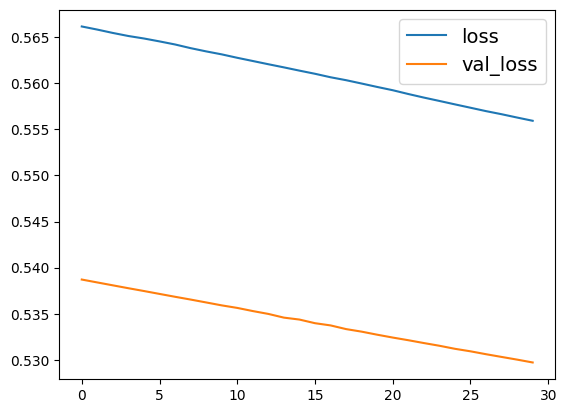

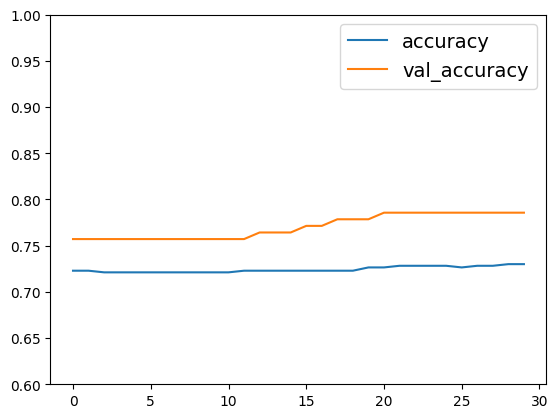

In [ ]:
#Compilação + loss function + melhor modelo
lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_CNN.fit(train_ds_1, epochs=30, validation_data = val_ds_1, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_ds1 += duration
tempo_total_ds1_min = tempo_total_ds1/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_ds1_min))

print (f'Tempo total de treino: {tempo_total_ds1_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))


print(f"Accuracy do melhor modelo: {max(history.history['val_accuracy']):.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
325 325
Accuracy - Dataset 1: 0.5754


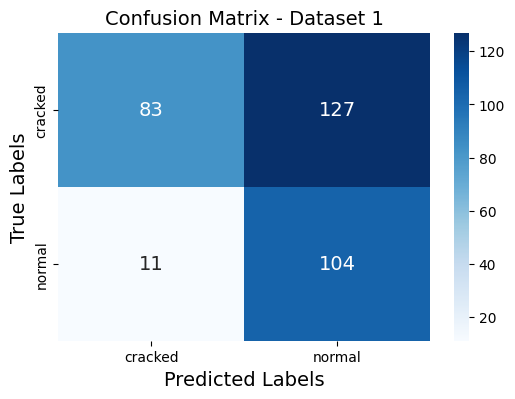

In [ ]:
model = keras.models.load_model('best_model.keras') #melhor modelo guardado

#Teste com Dataset 1
predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_1 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_1, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 113s 9s/step
372 372
Accuracy - Dataset 2: 0.7070


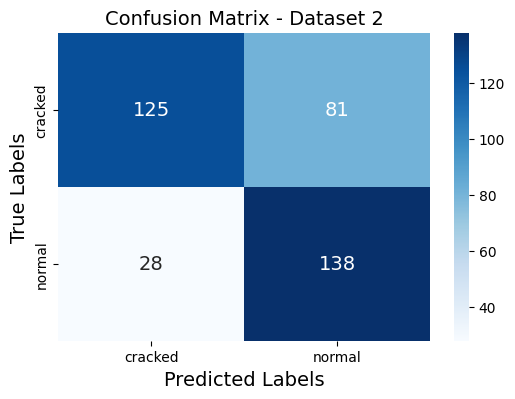

11/11 ━━━━━━━━━━━━━━━━━━━━ 96s 9s/step
345 345
Accuracy - Dataset 3: 0.6348


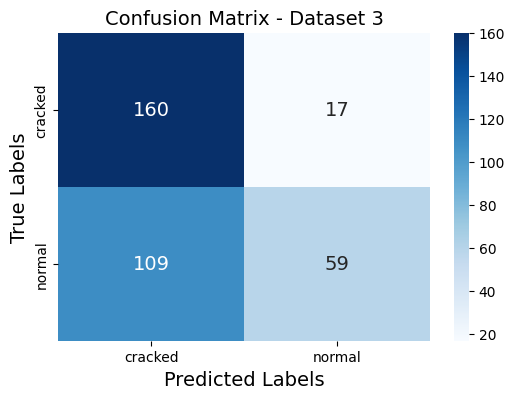

In [ ]:
#Teste com Dataset 2
predictions = model.predict(test_ds_2)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 2: {accuracy:.4f}')

confusion_matrix_2 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_2, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#--------------------------------------

#Teste com Dataset 3
predictions = model.predict(test_ds_3)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 3: {accuracy:.4f}')

confusion_matrix_3 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_3, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_3, yticklabels=class_names_3)
plt.title('Confusion Matrix - Dataset 3')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Treino com o Dataset 2

In [ ]:
keras.backend.clear_session()

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,905 (452.75 KB)

 Trainable params: 115,905 (452.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tempo_total_ds2 = 0

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.8310 - loss: 0.3871 - val_accuracy: 0.8243 - val_loss: 0.3749
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.8307 - loss: 0.3863 - val_accuracy: 0.8277 - val_loss: 0.3718
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.8337 - loss: 0.3850 - val_accuracy: 0.8311 - val_loss: 0.3731
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8337 - loss: 0.3851 - val_accuracy: 0.8311 - val_loss: 0.3725
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8337 - loss: 0.3842 - val_accuracy: 0.8311 - val_loss: 0.3720
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8352 - loss: 0.3840 - val_accuracy: 0.8277 - val_loss: 0.3699
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8334 - loss: 0.3824 - val_accuracy: 0.8311 - val_loss: 0.3706
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8330 - loss: 0.3822 - val_accuracy: 0.

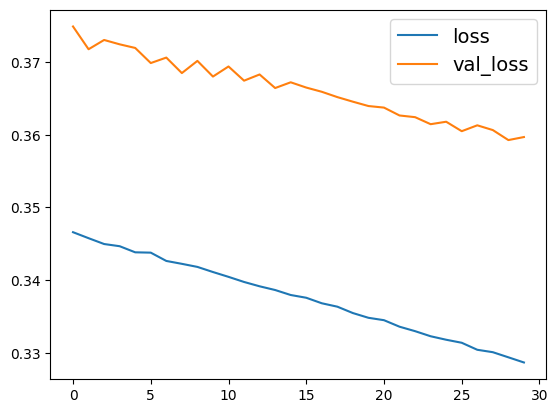

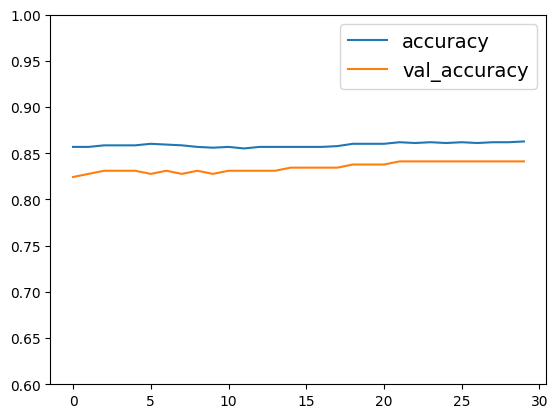

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_CNN.fit(train_ds_2, epochs=30, validation_data = val_ds_2, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_ds2 += duration
tempo_total_ds2_min = tempo_total_ds2/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_ds2_min))

print (f'Tempo total de treino: {tempo_total_ds2_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))


print(f"Accuracy do melhor modelo: {max(history.history['val_accuracy']):.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
372 372
Accuracy - Dataset 2: 0.8226


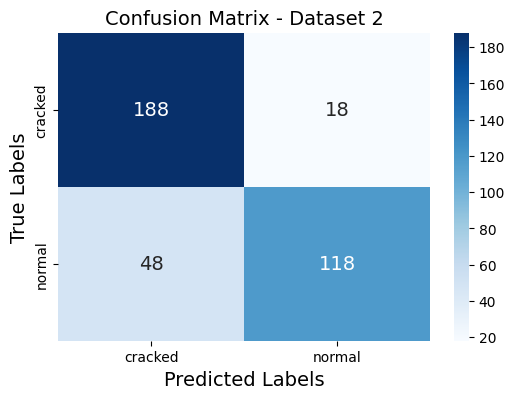

              precision    recall  f1-score   support

     cracked       0.80      0.91      0.85       206
      normal       0.87      0.71      0.78       166

    accuracy                           0.82       372
   macro avg       0.83      0.81      0.82       372
weighted avg       0.83      0.82      0.82       372

Tempo de inferência total:1.0067 segundos
Tempo de inferência por imagem: 0.0839s


In [ ]:
#Teste com Dataset 2
model = keras.models.load_model('best_model.keras')

start = time.time()
predictions = model.predict(test_ds_2)
end = time.time()
total = end - start
total_imagem = total/len(test_ds_2)

y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 2: {accuracy:.4f}')

confusion_matrix_4 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_4, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_true, y_pred, target_names = class_names_2))
print(f'Tempo de inferência total:{total:.4f} segundos')
print(f'Tempo de inferência por imagem: {total_imagem:.4f}s')

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
325 325
Accuracy - Dataset 1: 0.8092


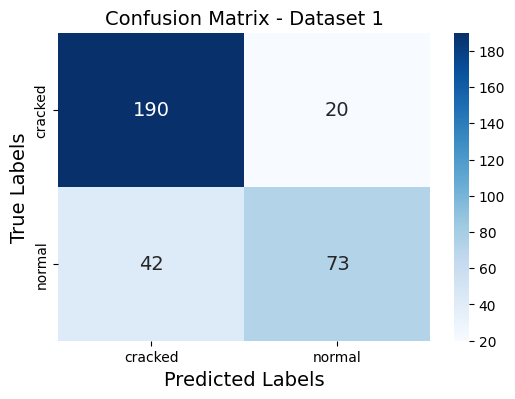

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
345 345
Accuracy - Dataset 3: 0.8348


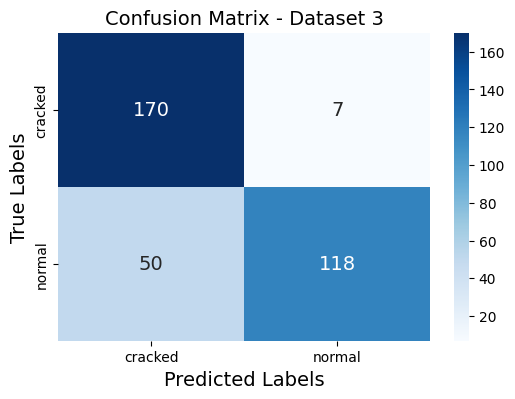

In [ ]:
#Teste com Dataset 1
predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_5 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_5, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#--------------------------------------

#Teste com Dataset 3
predictions = model.predict(test_ds_3)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 3: {accuracy:.4f}')

confusion_matrix_6 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_6, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_3, yticklabels=class_names_3)
plt.title('Confusion Matrix - Dataset 3')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
#exportar modelo

from google.colab import files
files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#para guardar no drive
!cp best_model.keras /content/drive/MyDrive/best_model.keras

## Treino com o Dataset 3

In [ ]:
keras.backend.clear_session()

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,905 (452.75 KB)

 Trainable params: 115,905 (452.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tempo_total_ds3 = 0

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - accuracy: 0.8255 - loss: 0.4161 - val_accuracy: 0.7852 - val_loss: 0.4577
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.8284 - loss: 0.4154 - val_accuracy: 0.7852 - val_loss: 0.4568
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.8284 - loss: 0.4146 - val_accuracy: 0.7852 - val_loss: 0.4559
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.8284 - loss: 0.4138 - val_accuracy: 0.7889 - val_loss: 0.4550
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.8284 - loss: 0.4130 - val_accuracy: 0.7926 - val_loss: 0.4542
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.8282 - loss: 0.4122 - val_accuracy: 0.7926 - val_loss: 0.4533
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8282 - loss: 0.4114 - val_accuracy: 0.7926 - val_loss: 0.4522
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.8286 - loss: 0.4106 - val_accuracy: 0.

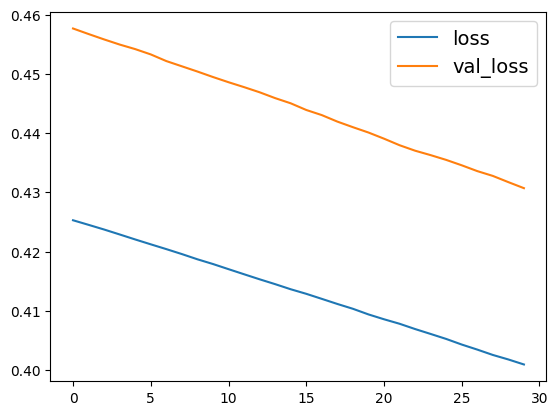

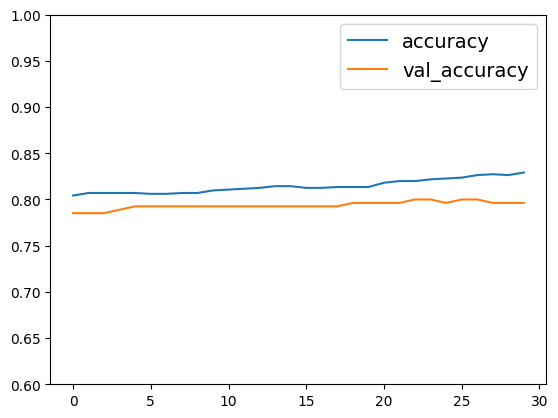

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_CNN.fit(train_ds_3, epochs=30, validation_data = val_ds_3, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_ds3 += duration
tempo_total_ds3_min = tempo_total_ds3/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_ds3_min))

print (f'Tempo total de treino: {tempo_total_ds3_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))


print(f"Accuracy do melhor modelo: {max(history.history['val_accuracy']):.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
345 345
Accuracy - Dataset 3: 0.8174


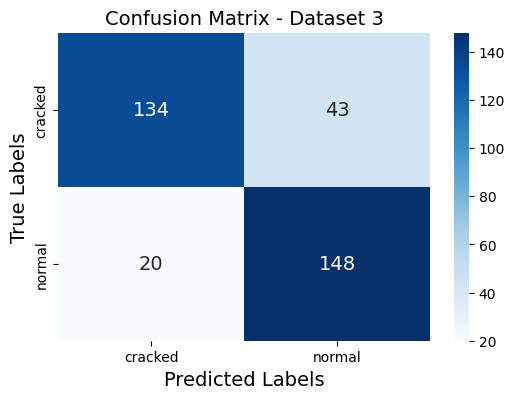

In [ ]:
#Teste com Dataset 3
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_3)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 3: {accuracy:.4f}')

confusion_matrix_7 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_7, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_3, yticklabels=class_names_3)
plt.title('Confusion Matrix - Dataset 3')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
325 325
Accuracy - Dataset 1: 0.4246


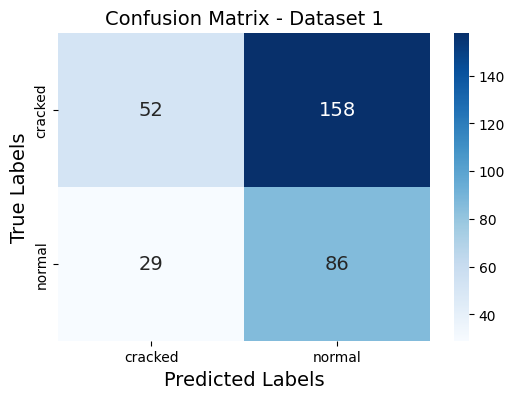

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
372 372
Accuracy - Dataset 2: 0.5430


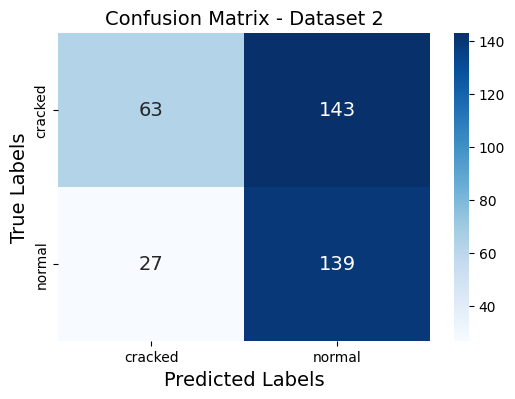

In [ ]:
#Teste com Dataset 1
predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_8 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_8, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#--------------------------------------

#Teste com Dataset 2
predictions = model.predict(test_ds_2)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 2: {accuracy:.4f}')

confusion_matrix_9 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_9, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Treino com um mix dos 3 Datasets

In [ ]:
keras.backend.clear_session()

In [ ]:
model_CNN = keras.Sequential([
    layers.Input(shape=(160,160,3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation= 'relu', padding='same'),
    layers.Conv2D(128, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation= 'relu', padding='same'),
    layers.MaxPooling2D(),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(1, activation= 'sigmoid')])

model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,905 (452.75 KB)

 Trainable params: 115,905 (452.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tempo_total_dsmix = 0

Epoch 1/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.7472 - loss: 0.5028 - val_accuracy: 0.7218 - val_loss: 0.5204
Epoch 2/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.7552 - loss: 0.4973 - val_accuracy: 0.7246 - val_loss: 0.5190
Epoch 3/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.7557 - loss: 0.4959 - val_accuracy: 0.7232 - val_loss: 0.5171
Epoch 4/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.7564 - loss: 0.4946 - val_accuracy: 0.7232 - val_loss: 0.5157
Epoch 5/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.7566 - loss: 0.4932 - val_accuracy: 0.7232 - val_loss: 0.5138
Epoch 6/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.7573 - loss: 0.4918 - val_accuracy: 0.7274 - val_loss: 0.5132
Epoch 7/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.7583 - loss: 0.4905 - val_accuracy: 0.7302 - val_loss: 0.5113
Epoch 8/60
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.7594 - loss: 0.4887 - val_accuracy: 0.733

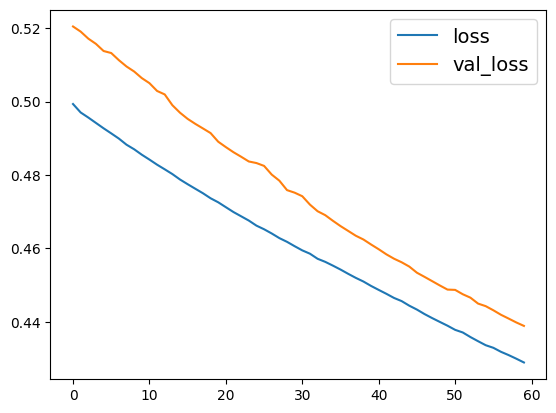

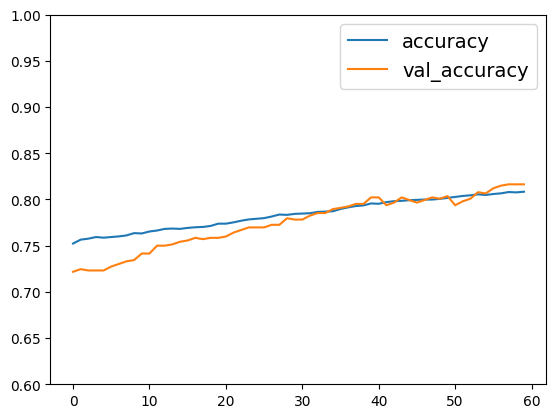

In [ ]:
#Compilação + loss function + melhor modelo

lossCNN = "binary_crossentropy"

model_CNN.compile(loss=lossCNN,
                  optimizer=keras.optimizers.SGD(),
                  metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_CNN.fit(dsmix_train, epochs=60, validation_data = dsmix_val, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_dsmix += duration
tempo_total_dsmix_min = tempo_total_dsmix/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_dsmix_min))

print (f'Tempo total de treino: {tempo_total_dsmix_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))

print(f"Accuracy do melhor modelo: {max(history.history['val_accuracy']):.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 150s 13s/step
325 325
Accuracy - Dataset 1: 0.7415


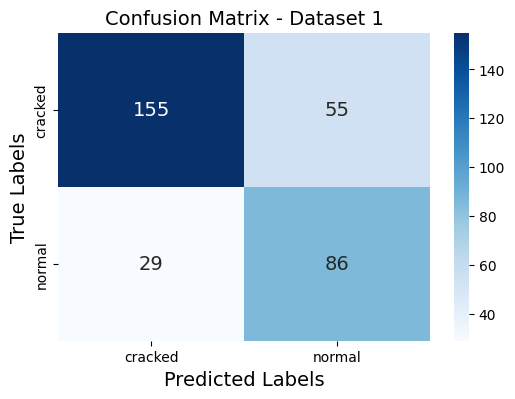

12/12 ━━━━━━━━━━━━━━━━━━━━ 157s 13s/step
372 372
Accuracy - Dataset 2: 0.7957


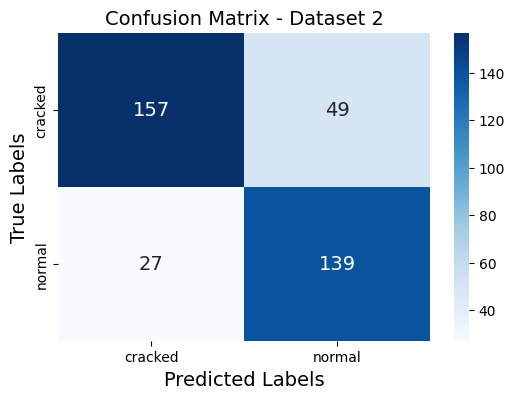

11/11 ━━━━━━━━━━━━━━━━━━━━ 159s 14s/step
345 345
Accuracy - Dataset 3: 0.8464


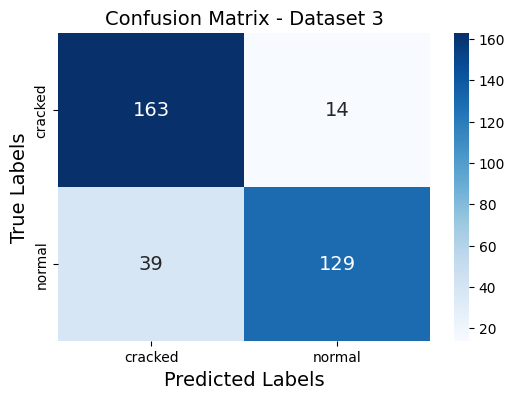

In [ ]:
#Teste com Dataset 1
model = keras.models.load_model('best_model.keras')

predictions = model.predict(test_ds_1)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_1], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_10 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_10, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_1, yticklabels=class_names_1)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#--------------------------------------

#Teste com Dataset 2
predictions = model.predict(test_ds_2)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 2: {accuracy:.4f}')

confusion_matrix_11 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_11, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#--------------------------------------

#Teste com Dataset 3
predictions = model.predict(test_ds_3)
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 3: {accuracy:.4f}')

confusion_matrix_12 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_12, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_3, yticklabels=class_names_3)
plt.title('Confusion Matrix - Dataset 3')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Transfer Learning


### ResNet50


In [ ]:
#fazer resize das imagens

In [ ]:
def resize_image(image, label):
  image = tf.image.resize(image, (224, 224))
  return image, label

train_ds_2_resized = train_ds_2.map(resize_image)
val_ds_2_resized = val_ds_2.map(resize_image)
test_ds_2_resized = test_ds_2.map(resize_image)

- Parte congelada

In [ ]:
from tensorflow.keras import applications
from tensorflow.keras.applications.resnet50 import ResNet50

In [ ]:
ResNet_base = keras.applications.resnet50.ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

ResNet_base.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

inputs = keras.Input(shape=(224, 224, 3))

x = keras.applications.resnet.preprocess_input(inputs)
x = ResNet_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)


model_RN = tf.keras.Model(inputs, outputs)
model_RN.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    131,136 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
tempo_total_RN = 0

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 700s 18s/step - accuracy: 0.6823 - loss: 0.5905 - val_accuracy: 0.8784 - val_loss: 0.3010
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - accuracy: 0.8891 - loss: 0.2715 - val_accuracy: 0.9155 - val_loss: 0.2284
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.9062 - loss: 0.2162 - val_accuracy: 0.9223 - val_loss: 0.1998
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.9314 - loss: 0.1854 - val_accuracy: 0.9257 - val_loss: 0.1823
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.9453 - loss: 0.1636 - val_accuracy: 0.9324 - val_loss: 0.1712
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.9504 - loss: 0.1469 - val_accuracy: 0.9358 - val_loss: 0.1627
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9568 - loss: 0.1332 - val_accuracy: 0.9358 - val_loss: 0.1558
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.9638 - loss: 0.1215 - val_accuracy: 0

<Axes: >

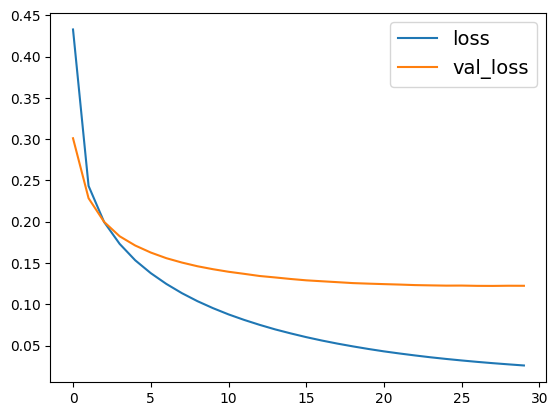

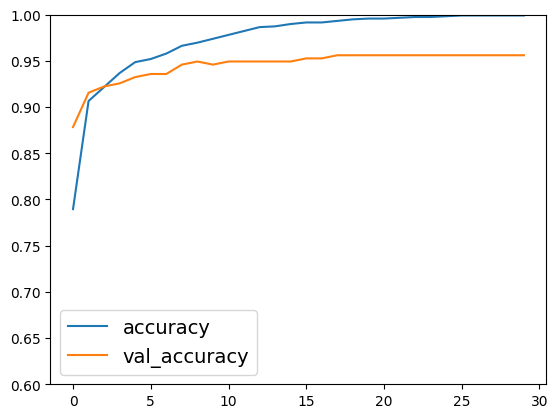

In [ ]:
lossCNN = "binary_crossentropy"

model_RN.compile(loss = lossCNN,
                 optimizer=keras.optimizers.SGD(),
                 metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_RN.fit(train_ds_2_resized, epochs=30, validation_data = val_ds_2_resized, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_RN += duration
tempo_total_RN_min = tempo_total_RN/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_RN_min))

print (f'Tempo total de treino: {tempo_total_RN_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))


12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 396ms/step
372 372
Accuracy - Dataset 1: 0.8952


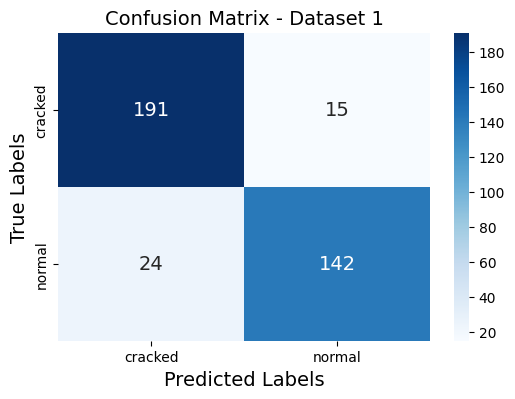

              precision    recall  f1-score   support

     cracked       0.89      0.93      0.91       206
      normal       0.90      0.86      0.88       166

    accuracy                           0.90       372
   macro avg       0.90      0.89      0.89       372
weighted avg       0.90      0.90      0.89       372

Tempo de inferência total:13.1991 segundos
Tempo de inferência por imagem: 1.0999s


In [ ]:
model_RN = keras.models.load_model('best_model.keras')

start = time.time()
predictions = model_RN.predict(test_ds_2_resized)
end = time.time()
total = end - start
total_imagem = total/len(test_ds_2_resized)

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(total_imagem))
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2_resized], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_13 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_13, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_true, y_pred, target_names = class_names_2))
print(f'Tempo de inferência total:{total:.4f} segundos')
print(f'Tempo de inferência por imagem: {total_imagem:.4f}s')

- Treina completamente

In [ ]:
keras.backend.clear_session()

In [ ]:
ResNet_base = keras.applications.resnet50.ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

ResNet_base.trainable = True

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

inputs = keras.Input(shape=(224, 224, 3))

x = keras.applications.resnet.preprocess_input(inputs)
x = ResNet_base(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)


model_RN = tf.keras.Model(inputs, outputs)
model_RN.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    131,136 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 23,665,793 (90.28 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
tempo_total_RN = 0

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 63s 858ms/step - accuracy: 0.7307 - loss: 0.5144 - val_accuracy: 0.9324 - val_loss: 0.2127
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 294ms/step - accuracy: 0.9744 - loss: 0.1087 - val_accuracy: 0.9392 - val_loss: 0.1681
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 296ms/step - accuracy: 0.9976 - loss: 0.0430 - val_accuracy: 0.9426 - val_loss: 0.1509
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 260ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.9426 - val_loss: 0.1401
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 302ms/step - accuracy: 1.0000 - loss: 0.0160 - val_accuracy: 0.9493 - val_loss: 0.1320
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 299ms/step - accuracy: 1.0000 - loss: 0.0115 - val_accuracy: 0.9527 - val_loss: 0.1248
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 284ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.9561 - val_loss: 0.1211
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accu

<Axes: >

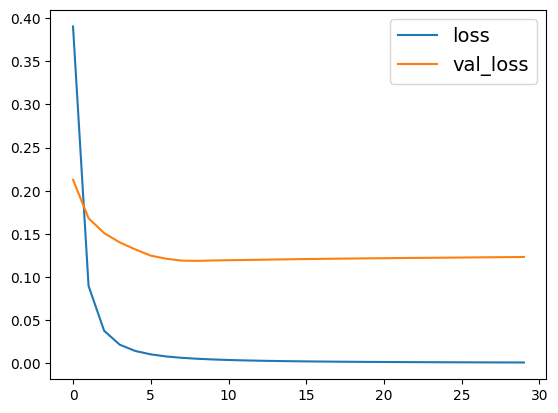

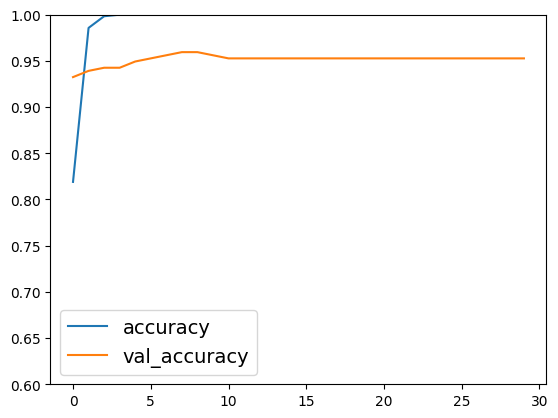

In [ ]:
lossCNN = "binary_crossentropy"

model_RN.compile(loss = lossCNN,
                 optimizer=keras.optimizers.SGD(),
                 metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_RN.fit(train_ds_2_resized, epochs=30, validation_data = val_ds_2_resized, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_RN += duration
tempo_total_RN_min = tempo_total_RN/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_RN_min))

print (f'Tempo total de treino: {tempo_total_RN_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))


12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step
372 372
Accuracy - Dataset 1: 0.9113


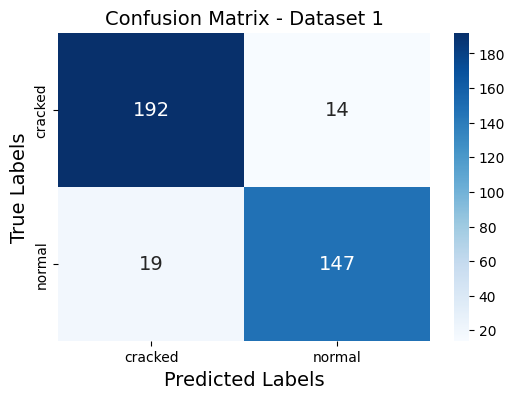

              precision    recall  f1-score   support

     cracked       0.91      0.93      0.92       206
      normal       0.91      0.89      0.90       166

    accuracy                           0.91       372
   macro avg       0.91      0.91      0.91       372
weighted avg       0.91      0.91      0.91       372

Tempo de inferência total:10.2373 segundos
Tempo de inferência por imagem:  0.8531s


In [ ]:
import time

model_RN = keras.models.load_model('best_model.keras')

start = time.time()
predictions = model_RN.predict(test_ds_2_resized)
end = time.time()
total = end - start
total_imagem = total/len(test_ds_2_resized)

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(total_imagem))
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2_resized], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_14 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_14, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_true, y_pred, target_names = class_names_2))
print(f'Tempo de inferência total:{total:.4f} segundos')
print(f'Tempo de inferência por imagem: {total_imagem: .4f}s')

### Inception V3

In [ ]:
def resize_image(image, label):
  image = tf.image.resize(image, (299, 299))
  return image, label

train_ds_2_IV3 = train_ds_2.map(resize_image)
val_ds_2_IV3 = val_ds_2.map(resize_image)
test_ds_2_IV3 = test_ds_2.map(resize_image)

- Parte congelada

In [ ]:
from tensorflow.keras.applications import InceptionV3

Inception_base = InceptionV3 (weights="imagenet", include_top=False, input_shape=(299,299,3))

Inception_base.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

inputs = keras.Input(shape=(299, 299, 3))

x = keras.applications.inception_v3.preprocess_input(inputs)
x = Inception_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_IV3 = tf.keras.Model(inputs, outputs)
model_IV3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,933,985 (83.67 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
tempo_total_IV3 = 0

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 596ms/step - accuracy: 0.8561 - loss: 0.3578 - val_accuracy: 0.8649 - val_loss: 0.3286
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - accuracy: 0.8732 - loss: 0.3157 - val_accuracy: 0.8784 - val_loss: 0.2959
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.8927 - loss: 0.2871 - val_accuracy: 0.8750 - val_loss: 0.2728
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.8964 - loss: 0.2660 - val_accuracy: 0.8986 - val_loss: 0.2551
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9054 - loss: 0.2490 - val_accuracy: 0.9054 - val_loss: 0.2417
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9101 - loss: 0.2350 - val_accuracy: 0.9054 - val_loss: 0.2305
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.9259 - loss: 0.2228 - val_accuracy: 0.9054 - val_loss: 0.2216
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.9282 - loss: 0.2120 - val_accura

<Axes: >

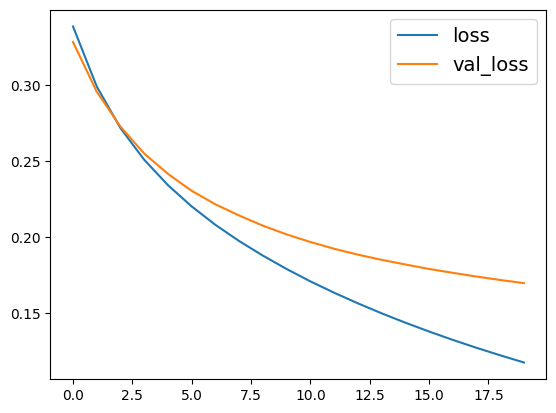

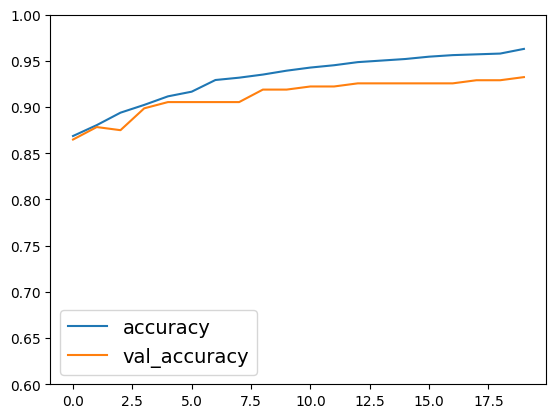

In [ ]:
lossCNN = "binary_crossentropy"

model_IV3.compile(loss = lossCNN,
                 optimizer=keras.optimizers.SGD(),
                 metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_IV3.fit(train_ds_2_IV3, epochs=20, validation_data = val_ds_2_IV3, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_IV3 += duration
tempo_total_IV3_min = tempo_total_IV3/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_IV3_min))

print (f'Tempo total de treino: {tempo_total_IV3_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 604ms/step
372 372
Accuracy - Dataset 1: 0.8978


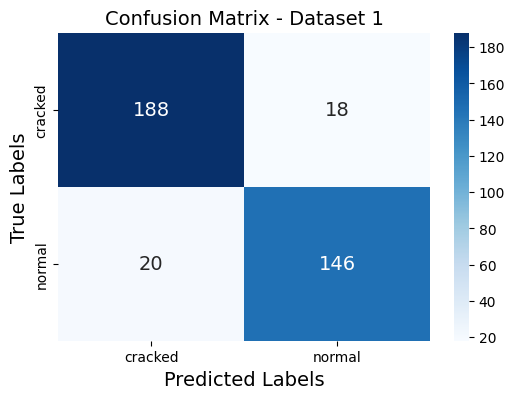

              precision    recall  f1-score   support

     cracked       0.90      0.91      0.91       206
      normal       0.89      0.88      0.88       166

    accuracy                           0.90       372
   macro avg       0.90      0.90      0.90       372
weighted avg       0.90      0.90      0.90       372

Tempo de inferência total:20.4697 segundos
Tempo de inferência por imagem: 1.7058 s


In [ ]:
import time

model_IV = keras.models.load_model('best_model.keras')

start = time.time()
predictions = model_IV.predict(test_ds_2_IV3)
end = time.time()
total = end - start
total_imagem = total/len(test_ds_2_IV3)

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(total_imagem))
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2_IV3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_15 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_15, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_true, y_pred, target_names = class_names_2))
print(f'Tempo de inferência total:{total:.4f} segundos')
print(f'Tempo de inferência por imagem: {total_imagem:.4f} s')

- Treina completamente

In [ ]:
keras.backend.clear_session()

In [ ]:
Inception_base = InceptionV3 (weights="imagenet", include_top=False, input_shape=(299,299,3))

Inception_base.trainable = True

In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

inputs = keras.Input(shape=(299, 299, 3))

x = keras.applications.inception_v3.preprocess_input(inputs)
x = Inception_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_IV3 = tf.keras.Model(inputs, outputs)
model_IV3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,933,985 (83.67 MB)

 Trainable params: 21,899,553 (83.54 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
tempo_total_IV3 = 0

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.6816 - loss: 0.5990 - val_accuracy: 0.8615 - val_loss: 0.3508
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 71s 420ms/step - accuracy: 0.9342 - loss: 0.2605 - val_accuracy: 0.9189 - val_loss: 0.2356
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 414ms/step - accuracy: 0.9913 - loss: 0.1105 - val_accuracy: 0.9358 - val_loss: 0.1901
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - accuracy: 0.9981 - loss: 0.0538 - val_accuracy: 0.9459 - val_loss: 0.1714
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 434ms/step - accuracy: 0.9992 - loss: 0.0313 - val_accuracy: 0.9493 - val_loss: 0.1616
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 406ms/step - accuracy: 0.9992 - loss: 0.0206 - val_accuracy: 0.9426 - val_loss: 0.1564
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step - accuracy: 1.0000 - loss: 0.0146 - val_accuracy: 0.9426 - val_loss: 0.1556
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 393ms/step - accuracy: 1.0000 - loss: 0.0111 - val_accura

<Axes: >

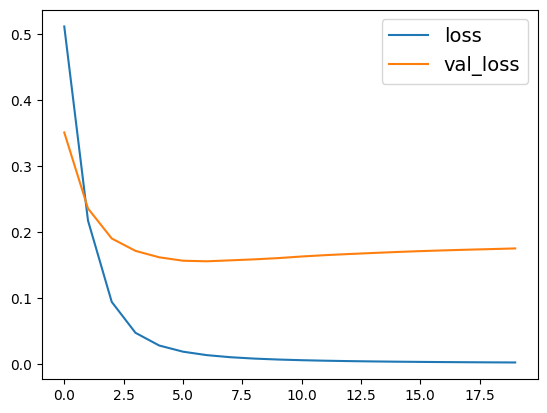

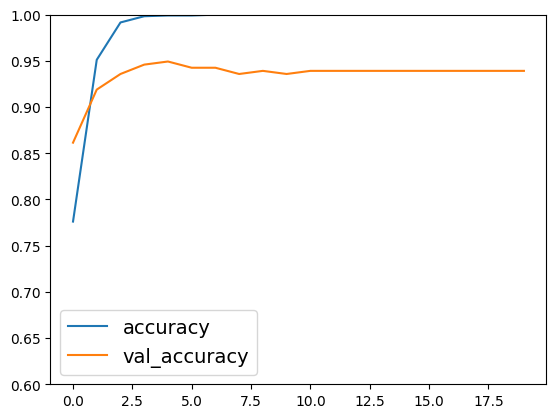

In [ ]:
lossCNN = "binary_crossentropy"

model_IV3.compile(loss = lossCNN,
                 optimizer=keras.optimizers.SGD(),
                 metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_IV3.fit(train_ds_2_IV3, epochs=20, validation_data = val_ds_2_IV3, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_IV3 += duration
tempo_total_IV3_min = tempo_total_IV3/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_IV3_min))

print (f'Tempo total de treino: {tempo_total_IV3_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 689ms/step
372 372
Accuracy - Dataset 1: 0.9140


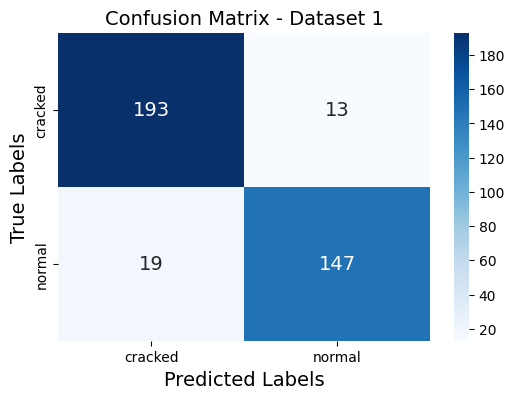

              precision    recall  f1-score   support

     cracked       0.91      0.94      0.92       206
      normal       0.92      0.89      0.90       166

    accuracy                           0.91       372
   macro avg       0.91      0.91      0.91       372
weighted avg       0.91      0.91      0.91       372

Tempo de inferência total:20.4696 segundos
Tempo de inferência por imagem: 1.7058s


In [ ]:
import time

model_IV = keras.models.load_model('best_model.keras')

start = time.time()
predictions = model_IV.predict(test_ds_2_IV3)
end = time.time()
total = end - start
total_imagem = total/len(test_ds_2_IV3)

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(total_imagem))
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2_IV3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_16 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_16, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_true, y_pred, target_names = class_names_2))
print(f'Tempo de inferência total:{total:.4f} segundos')
print(f'Tempo de inferência por imagem: {total_imagem:.4f}s')

### EfficientNetB3

In [ ]:
def resize_image(image, label):
  image = tf.image.resize(image, (300, 300))
  return image, label

train_ds_2_EB3 = train_ds_2.map(resize_image)
val_ds_2_EB3 = val_ds_2.map(resize_image)
test_ds_2_EB3 = test_ds_2.map(resize_image)

In [ ]:
from tensorflow.keras.applications import EfficientNetB3

- Parte congelada

In [ ]:
from tensorflow.keras.applications import EfficientNetB3

EfficientNetB3_base = EfficientNetB3 (weights="imagenet", include_top=False, input_shape=(300,300,3))

EfficientNetB3_base.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

inputs = keras.Input(shape=(300, 300, 3))

x = keras.applications.efficientnet.preprocess_input(inputs)
x = EfficientNetB3_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_EB3 = tf.keras.Model(inputs, outputs)
model_EB3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,881,968 (41.51 MB)

 Trainable params: 98,433 (384.50 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
tempo_total_EB3 = 0

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.6667 - loss: 0.6221 - val_accuracy: 0.8345 - val_loss: 0.4921
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.8260 - loss: 0.4651 - val_accuracy: 0.8818 - val_loss: 0.3960
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.8660 - loss: 0.3795 - val_accuracy: 0.8986 - val_loss: 0.3399
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.8797 - loss: 0.3347 - val_accuracy: 0.9020 - val_loss: 0.3044
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.8886 - loss: 0.3016 - val_accuracy: 0.9054 - val_loss: 0.2790
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - accuracy: 0.8931 - loss: 0.2777 - val_accuracy: 0.9189 - val_loss: 0.2613
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.8903 - loss: 0.2672 - val_accuracy: 0.9155 - val_loss: 0.2467
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.8966 - loss: 0.2525 - val_accuracy: 

<Axes: >

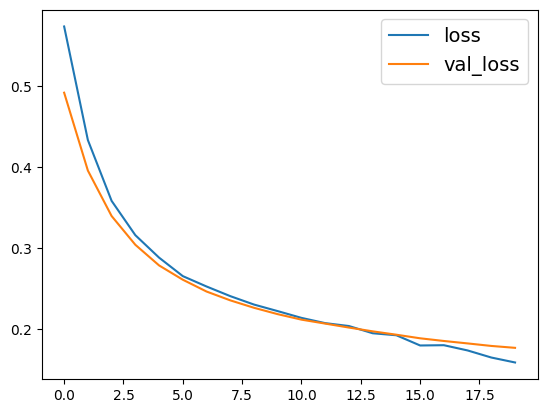

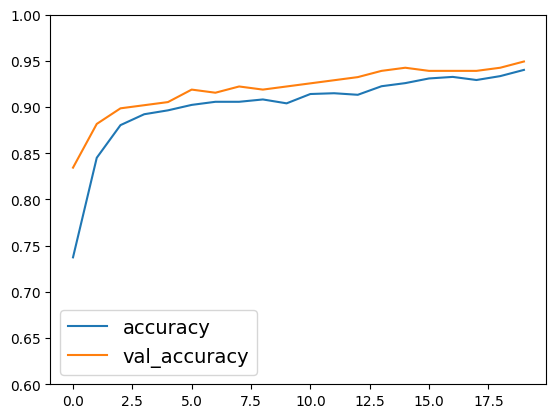

In [ ]:
lossCNN = "binary_crossentropy"

model_EB3.compile(loss = lossCNN,
                 optimizer=keras.optimizers.SGD(),
                 metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_EB3.fit(train_ds_2_EB3, epochs=20, validation_data = val_ds_2_EB3, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_EB3 += duration
tempo_total_EB3_min = tempo_total_EB3/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_EB3_min))

print (f'Tempo total de treino: {tempo_total_EB3_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
372 372
Accuracy - Dataset 1: 0.8925


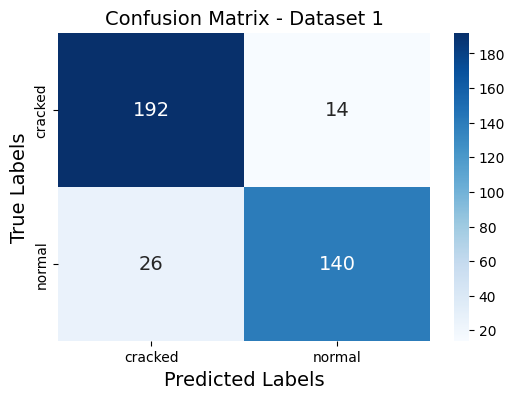

              precision    recall  f1-score   support

     cracked       0.88      0.93      0.91       206
      normal       0.91      0.84      0.88       166

    accuracy                           0.89       372
   macro avg       0.89      0.89      0.89       372
weighted avg       0.89      0.89      0.89       372

Tempo de inferência total:21.1010 segundos
Tempo de inferência por imagem: 1.7584s


In [ ]:
import time

model_EB = keras.models.load_model('best_model.keras')

start = time.time()
predictions = model_EB.predict(test_ds_2_EB3)
end = time.time()
total = end - start
total_imagem = total/len(test_ds_2_EB3)

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(total_imagem))
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2_EB3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_17 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_17, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_true, y_pred, target_names = class_names_2))
print(f'Tempo de inferência total:{total:.4f} segundos')
print(f'Tempo de inferência por imagem: {total_imagem:.4f}s')

- Treina completamente

In [ ]:
EfficientNetB3_base = EfficientNetB3 (weights="imagenet", include_top=False, input_shape=(300,300,3))

EfficientNetB3_base.trainable = True

In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

inputs = keras.Input(shape=(300, 300, 3))

x = keras.applications.efficientnet.preprocess_input(inputs)
x = EfficientNetB3_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_EB3 = tf.keras.Model(inputs, outputs)
model_EB3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,881,968 (41.51 MB)

 Trainable params: 10,794,665 (41.18 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [ ]:
tempo_total_EB3 = 0

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.5139 - loss: 0.7009 - val_accuracy: 0.6385 - val_loss: 0.6445
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 468ms/step - accuracy: 0.7563 - loss: 0.5792 - val_accuracy: 0.7500 - val_loss: 0.5588
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 469ms/step - accuracy: 0.8522 - loss: 0.4782 - val_accuracy: 0.8547 - val_loss: 0.4707
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 481ms/step - accuracy: 0.8873 - loss: 0.3906 - val_accuracy: 0.8953 - val_loss: 0.3900
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 491ms/step - accuracy: 0.9210 - loss: 0.3155 - val_accuracy: 0.9223 - val_loss: 0.3263
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 474ms/step - accuracy: 0.9274 - loss: 0.2589 - val_accuracy: 0.9358 - val_loss: 0.2844
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 449ms/step - accuracy: 0.9540 - loss: 0.2098 - val_accuracy: 0.9291 - val_loss: 0.2485
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.9597 - loss: 0.1719 - val_accura

<Axes: >

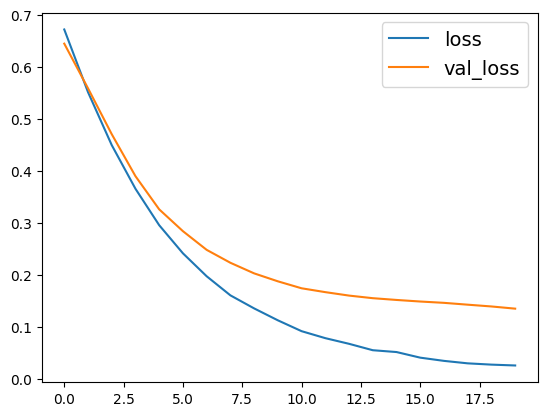

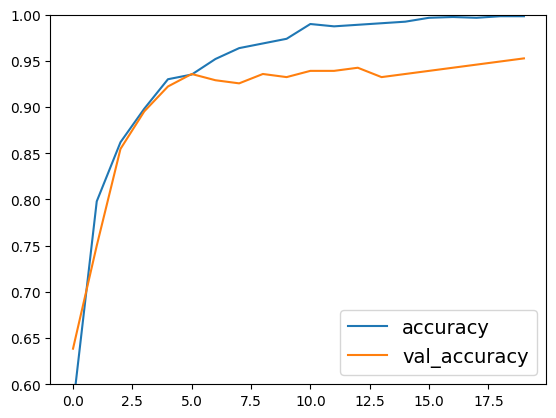

In [ ]:
lossCNN = "binary_crossentropy"

model_EB3.compile(loss = lossCNN,
                 optimizer=keras.optimizers.SGD(),
                 metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max')

start = time.time()

history = model_EB3.fit(train_ds_2_EB3, epochs=20, validation_data = val_ds_2_EB3, callbacks=[checkpoint])

end = time.time()
duration = end - start
tempo_total_EB3 += duration
tempo_total_EB3_min = tempo_total_EB3/60

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(tempo_total_EB3_min))

print (f'Tempo total de treino: {tempo_total_EB3_min: .2f} min')

#Gráficos de evolução
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot(ylim=(0.60,1.00))

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
372 372
Accuracy - Dataset 1: 0.9247


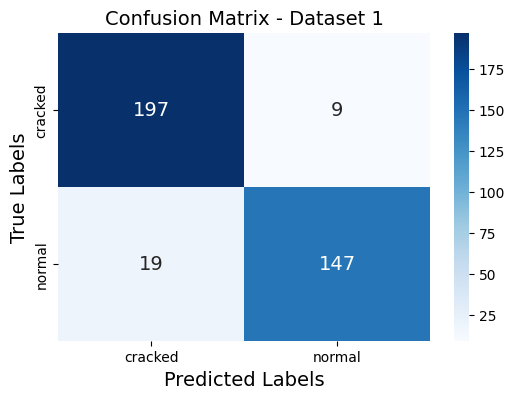

              precision    recall  f1-score   support

     cracked       0.91      0.96      0.93       206
      normal       0.94      0.89      0.91       166

    accuracy                           0.92       372
   macro avg       0.93      0.92      0.92       372
weighted avg       0.93      0.92      0.92       372

Tempo de inferência total:40.9486 segundos
Tempo de inferência por imagem: 3.4124s


In [ ]:
import time

model_EB = keras.models.load_model('best_model.keras')

start = time.time()
predictions = model_EB.predict(test_ds_2_EB3)
end = time.time()
total = end - start
total_imagem = total/len(test_ds_2_EB3)

with open('tempo_total_ds1.txt', 'w') as f:
  f.write(str(total_imagem))
y_pred = np.where(predictions> 0.5, 1, 0)

y_pred_classes = (predictions > 0.5).astype(int)  # Para classificação binária

# True labels para test_ds
y_true = np.concatenate([y for x, y in test_ds_2_EB3], axis=0)

y_pred_classes = y_pred_classes.flatten()

print(len(y_true), len(y_pred_classes))

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy - Dataset 1: {accuracy:.4f}')

confusion_matrix_18 = confusion_matrix(y_true,y_pred)
plt.figure (figsize = (6, 4))
sns.heatmap(confusion_matrix_18, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_2, yticklabels=class_names_2)
plt.title('Confusion Matrix - Dataset 1')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print(classification_report(y_true, y_pred, target_names = class_names_2))
print(f'Tempo de inferência total:{total:.4f} segundos')
print(f'Tempo de inferência por imagem: {total_imagem:.4f}s')